# Google Trends Analysis 
Example from Morocco's 2023 Earthquake Response

## About the data
Google Trends tells what people are searching for, in real time. This data can be use to measure search interest in a particular topic, in a particular place, and at a particular time.

This tool canbe explored for free in the [Trends Explore Tool](https://trends.google.com/trends/?geo=US). With that tool, as well as when using the private API key, one can search google trends filtering by:
- Country: Where the searches are being done
- Date range
- Terms or Topics: Terms, like any other Google search are the terms to look for. Topics, on the other hand, are generally considered to be more reliable for Google Trends data. They pull in the exact phrase as well as misspellings and acronyms, and cover all languages. This is more useful, particularly when looking at world data.


[Basics of Google Trends](https://newsinitiative.withgoogle.com/resources/trainings/google-trends/basics-of-google-trends/)

As an example, we downloaded Google Trends data for Simon Biles from 2004 till now. It can be seen that every four years, the olympiad span, her name gets more relevance. 

<center><div>
    <img src="./images/simone_biles.png" width="800"/>
</div></center>




## Methodology - Moroccos's 2023 Earthquate Response

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime as dt

from googleapiclient.discovery import build

from statsmodels.tsa.filters.hp_filter import hpfilter
import scipy.stats as stats

from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from sklearn.metrics import mean_squared_error 
from math import sqrt 

import plotly.express as px
import plotly.graph_objects as go

%matplotlib inline

### Analyzing Google Trends 
The below analysis was performed days after September 2023 Morocco's earthquake happened. It tries to answer the question if the earthquake in Morocco was affecting the tourism industry. It made use of proprietary Google Trends data that gives weekly data scaled to the highest result from 0 to 100 i.e. 100 representing the highest proportion for the terms queried within the selected region and time frame and zero the lowest. 

The analysis focused on 5 countries in specific, the ones that make up for the highest number of visitors in Morocco: **France**, **Germany**, **Spain**, **United Kingdom**, **United States**. Thus, a list of commonly used terms that people tend to use to plan their holidays was created. The kinds of searches that users perform can be a good proxy for the public’s interests, concerns or intentions, but these searches do not necessarily represent users’ opinions. Therefore the analysis uses statistical methods to come up with a probabilistic analysis of impact on Morocco's tourism industry.

The followign code uses Classes and Methods. If you are not familiar with this programming methodology, you can find more by searching for Object Oriented Prgramming (OOP)

In [2]:
class Google():
    """
    Wrapper class for handling authentication and requests (GET) to Google API
    
    Parameters
    ----------
    token : str
        Google API token
        
    Notes
    -----
    For more information, please see https://developers.google.com/apis-explorer
    """
    
    def __init__(self, token=None):
        self.TOKEN = token if token else os.getenv("GOOGLE_TOKEN")
        
    @property
    def service(self):
        """Authenticate and instantiate Google API service"""
        return build('trends', 'v1beta', static_discovery=False, developerKey=self.TOKEN)

    def get(self, method, params):
        """Get result from Google API method"""
        return getattr(self.service, method)(**params).execute()
    
    
    def download(self, method, params):
        """Download result from Google API method"""
        
        if not method in ["getGraph", "getTimelinesForHealth"]:
            raise NotImplementedError("Method not supported.")
        
        result = self.get(method, params)
        
        df = pd.json_normalize(result["lines"], meta=["term"], record_path=["points"]) 
        
        params = "+".join([f"{k}={v}" for k, v in params.items()])
        name = f"{method}+{params}.csv"

        df.to_csv(name, index=False)

In [3]:
# Instantiate your Google class to start querying
google = Google()

##### Lists of commonly used travel search terms in different languages catering to United States, United Kingdom, France, Germany and Spain. 

In [4]:
eng_terms = ['morocco flights', 'morocco hotels', 'marrakesh', 'marrakesh hotels', 'casablanca morocco','casablanca hotels', 
         'casablanca flights', 'casablanca travel', 'morocco tourist attractions', 'things to do in morocco', 'things to do in casablanca',
         "moroccan cuisine", "beaches in morocco", "Safety in Morocco", "transportation in Morocco"]

In [5]:
french_terms = ['séjour à marrakech', "vacance maroc", "voyages marrakech", "billet avion Maroc", "casablanca hotels", "marrakech hotels",
                "Cuisine marocaine", "Sécurité au Maroc"]

In [6]:
spanish_terms = ['Vuelos a Marruecos', 'Hoteles en Marruecos', 'Casablanca Marruecos', 'Hoteles en Casablanca', 'Vuelos a Casablanca', 'Viaje a Marruecos', 'Que hacer en Marruecos',
                 "Rutas por Marruecos", "Playas en Marruecos", "Seguridad en Marruecos"]

In [7]:
german_terms = ['Marokko Hotels', 'Hotels in Marrakesch', "things to do in morocco", "Pauschalreisen Marokko", "Marokko Sehenswürdigkeiten",
                "Marokko Rundreise", "Marokko Strände", "Marokko Sicherheit", "Marokko Transport"]

In [8]:
con_dict = {"US" :  "United States", "GB" : "United Kingdom", "ES" : "Spain", "FR" : "France", "DE" : "Germany"}

In [9]:
def get_df(terms, country, start_date = None, end_date = None):
    """
    Function to get a dataframe for specified list of terms, country iso2 code and start/end date strings

    Return:
    Pandas Dataframe
    """
    df = pd.DataFrame()
    for term in terms:
        filters = {
            'terms': [term],
            'restrictions_geo': country,
            'restrictions_startDate': start_date,
            'restrictions_endDate' : end_date
        }

        r = google.get('getGraph', filters)
        df_ = pd.DataFrame(r["lines"][0]["points"])
        df_['query'] = term

        df = pd.concat([df, df_], axis = 0)

    return df

In [10]:
def trenddetector(list_of_index, array_of_data, order=1):
    """
    Helper function to detect upward or downward trend in time series using `order` degree polynomial function

    Returns:
    Slope of the polynomial function 
    """
    result = np.polyfit(list_of_index, list(array_of_data), order)
    slope = result[-2]
    return float(slope)

def get_country_df(country, start_date, end_date = None):
    """
    Function to retrieve country level data for each of the search terms and return an aggregated Dataframe

    Returns:
    Pandas Dataframe
    """

    if country in ['US', 'GB']:
        df = get_df(eng_terms, country, start_date, end_date)
    elif country == 'FR':
        df = get_df(french_terms, country, start_date, end_date)
    elif country == 'ES':
        df = get_df(spanish_terms, country, start_date, end_date)
    elif country == 'DE':
        df = get_df(german_terms, country, start_date, end_date)

    df_grp = df.groupby(['date'])[['value']].mean()

    return df_grp


This example downloads the data from January 2023 till the 12th of November of 2023 when the analysis was performed.

In [11]:
df2023 = pd.DataFrame()
for country in ['US', 'GB', 'FR', 'ES', 'DE']:
    df_ = get_country_df(country, "2023-01", "2023-09")

    df_['country'] = con_dict[country]

    df2023 = pd.concat([df2023, df_])
df2023['month'] = [dt.strptime(i, "%Y-%m-%d").strftime("%b-%d") for i in df2023.index]

In [12]:
df2023.describe()

,value
count,195.000000
mean,29.490128
std,11.476311
min,0.000000
25%,21.316667
50%,31.800000
75%,38.162500
max,52.000000


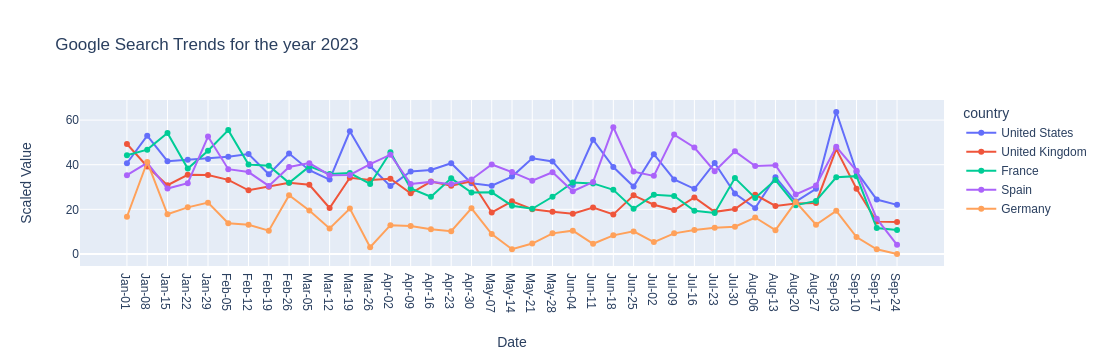

In [22]:
fig = px.line(df2023, x='month', y='value', color='country', markers=True, title = f"Google Search Trends for the year 2023")
fig.update_yaxes(
        title_text = "Scaled Value",
        title_standoff = 25)
fig.update_xaxes(
        title_text = "Date",
        title_standoff = 25)

fig.show()

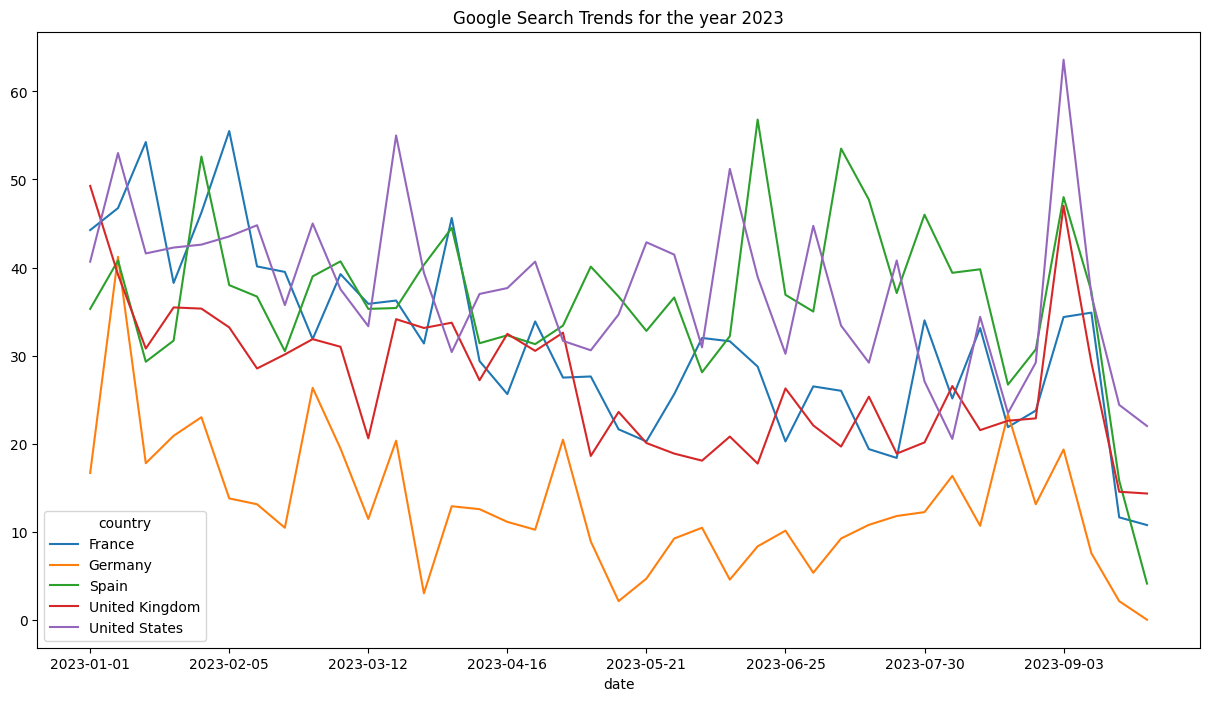

In [23]:
ax = df2023.reset_index().pivot(index = 'date', columns = 'country', values = 'value').plot(figsize = (15, 8))
ax.set_title("Google Search Trends for the year 2023", fontsize = 12);

##### Comparing the trends for the past 3 years for the same time period (Jan - Sept)

In [39]:
def download_several_countries(list_countries, period_start, period_end):
    df = pd.DataFrame()
    for country in list_countries:
        df_ = get_country_df(country, period_start, period_end)
    
        df_['country'] = con_dict[country]
    
        df = pd.concat([df, df_])
    df['month'] = [dt.strptime(i, "%Y-%m-%d").strftime("%b-%d") for i in df.index]
    return df

In [40]:
# Download the data with automation function
list_countries = ['US', 'GB', 'FR', 'ES', 'DE']
df2022 = download_several_countries(list_countries, "2022-01", "2022-09")
df2021 = download_several_countries(list_countries, "2021-01", "2021-09")

In [41]:
def plot_charts(country, df_curr, df_year1, df_year2):
    ax = df_curr.plot(figsize = (14,8))
    df_year1.plot(ax=ax)
    df_year2.plot(ax=ax)
    handles, previous_labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=["2023 trends (Jan-Sept)", "2022 trends (Jan-Sept)", "2021 trends (Jan-Sept)"])
    ax.set_title(f"{con_dict[country]} Trends Analysis");
    ax.set_ylim(0,100);

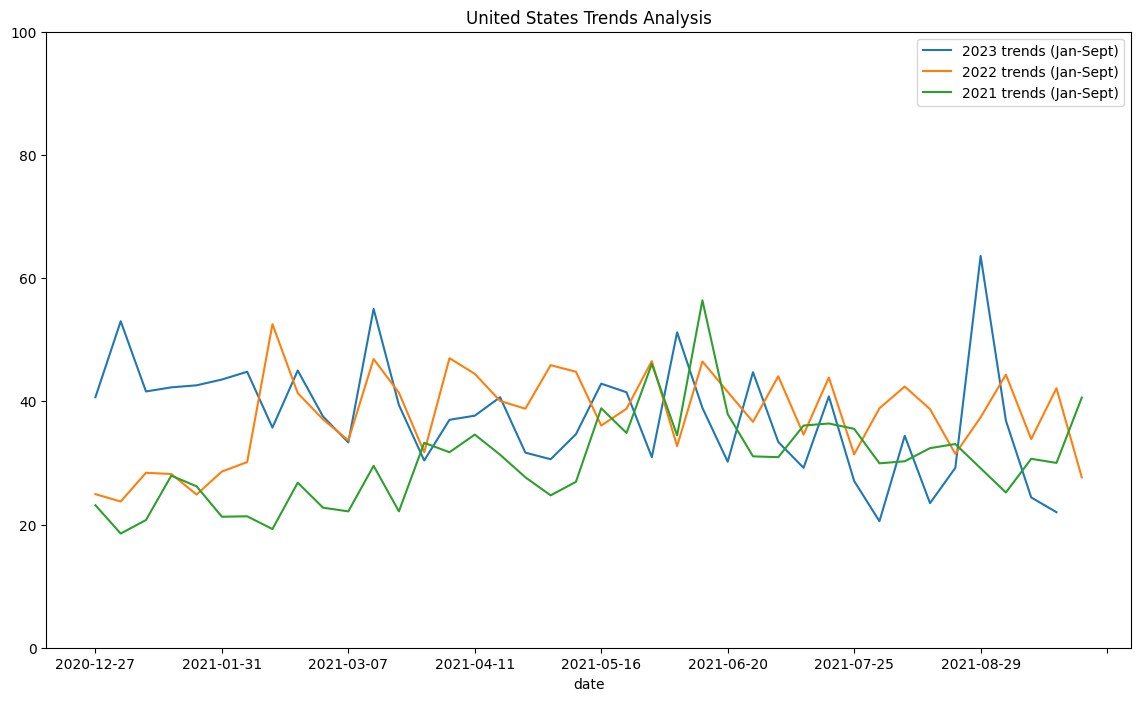

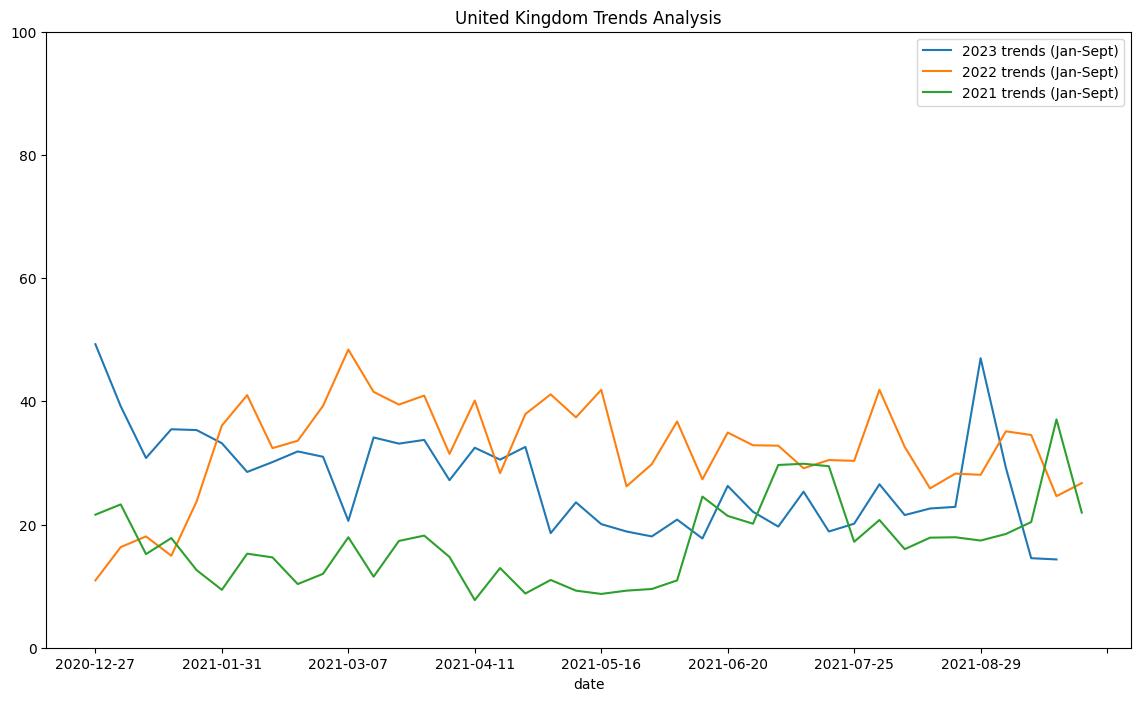

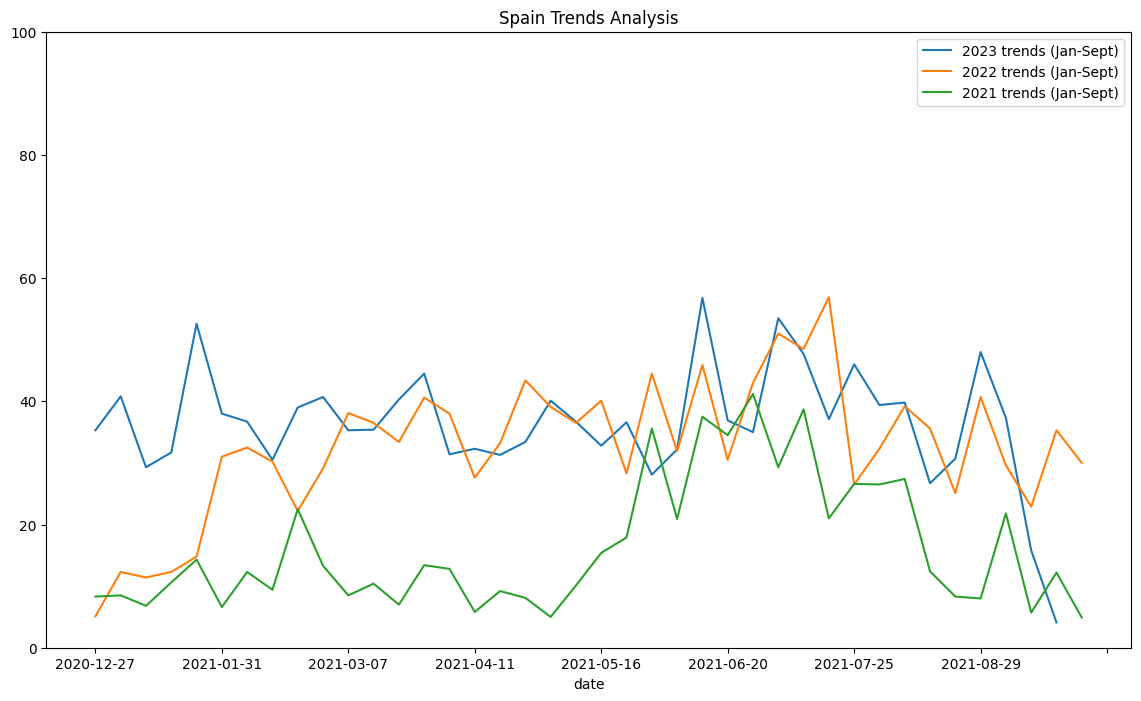

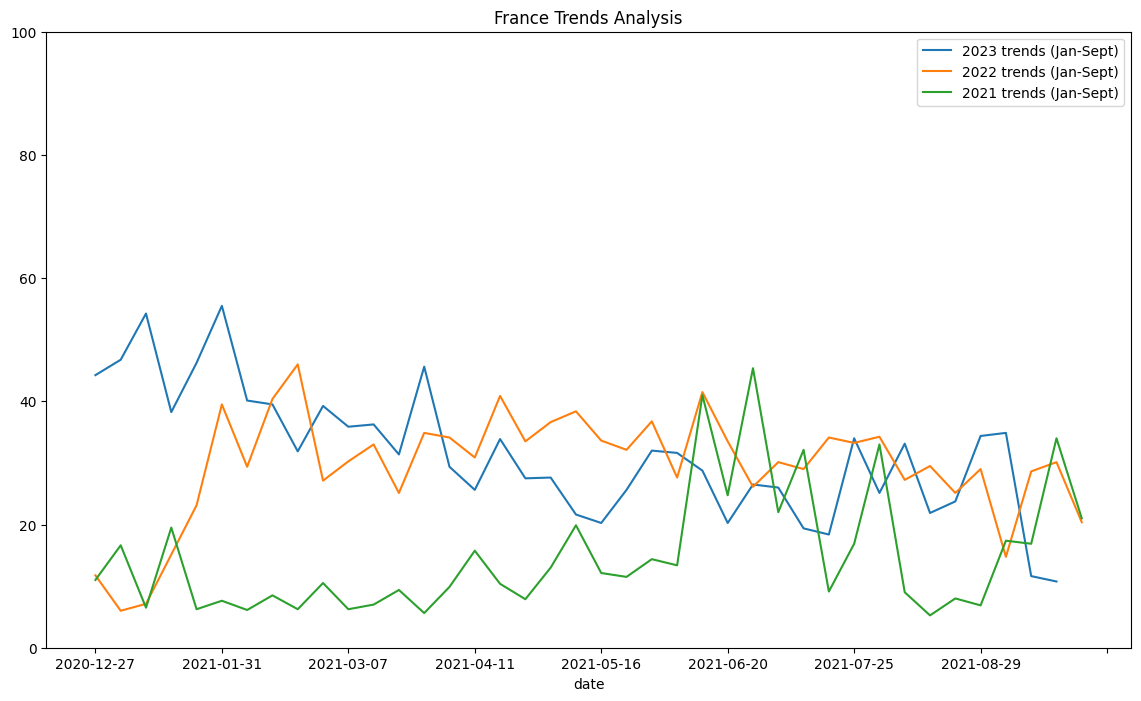

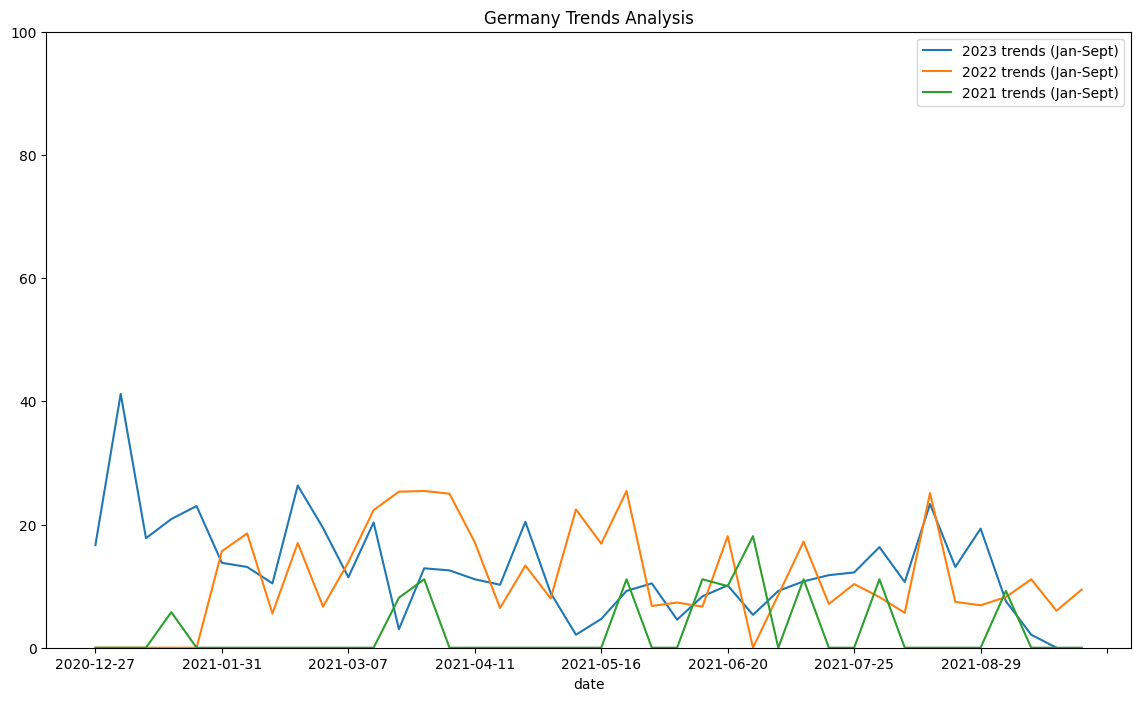

In [42]:
for abbr, name in con_dict.items():
    plot_charts(abbr, df2023[df2023['country']==name], df2022[df2022['country']==name], df2021[df2021['country']==name])

Overall, as expected, 2021 saw very little search travel terms to Morocco because of COVID restrictions and people not willing to travel internationally unless things were safer. 2022 was one of the busiest year for travel in a decade and the trends in plots above show that. For 2023, the trends went slightly down but some months show spikes in search for travel terms. 

### Prediction

To predict if the tourism will be impacted using Google Trends data,  data points for set query terms from 2019 to latest available date (removing the time periods when the country was under COVID lockdown) were collected

Specific terms related to flight/hotel cancellation were used but Google Trends did not have enough data to show that. This prediction is solely based on yearly trends and seasonality. 

In [61]:
def predict_trends(country):
    df1 = get_country_df(country, "2019-01", "2020-03")
    df2 = get_country_df(country, "2021-10")

    df = pd.concat([df1, df2])

    ## Removing effects due to seasonality from the time series
    try:
        result_mul = seasonal_decompose(df.value,model='multiplicative', extrapolate_trend='freq', period = 12)
    except ValueError:
        result_mul = seasonal_decompose(df.value,model='additive', extrapolate_trend='freq', period = 12)
    deseason = df.value - result_mul.seasonal

    ##spilitting the data into train/test set

    Train = pd.DataFrame(deseason[:-60], columns = ['value'])
    valid = pd.DataFrame(deseason[-60:], columns = ['value'])

    ## Fitting the data to Holt's model
    y_hat_avg = pd.DataFrame(valid).copy() 
    fit1 = Holt(np.asarray(Train.value)).fit(smoothing_level = 0.5) #smoothing_level = 0.3, smoothing_slope = 0.1
    y_hat_avg['Holt_linear'] = fit1.forecast(len(valid))

    rms = sqrt(mean_squared_error(valid.value, y_hat_avg.Holt_linear)) 
    print(f"RMS error for {con_dict[country]}'s data is {rms:.3f}")

    y_hat_avg['date_ordinal'] = pd.to_datetime(y_hat_avg.index).map(dt.toordinal)
    slope, intercept, r_value, p_value, std_err = stats.linregress(y_hat_avg['date_ordinal'], y_hat_avg['Holt_linear'])

    if slope>0:
        print(f"Upward trend: {slope:.5f}")
    elif slope<0:
        print(f"Downward trend: {slope:.5f}")
    else:
        print("No trend")


    plt.figure(figsize=(20, 8))
    plt.plot(Train['value'], label='training data')
    plt.plot(valid['value'], label='test data') 
    plt.plot(y_hat_avg['Holt_linear'], label='predicted data') 
    plt.legend(loc='best') 
    plt.xticks(rotation = 90, fontsize = 7)
    plt.show()

RMS error for United States's data is 47.464
Upward trend: 0.15179


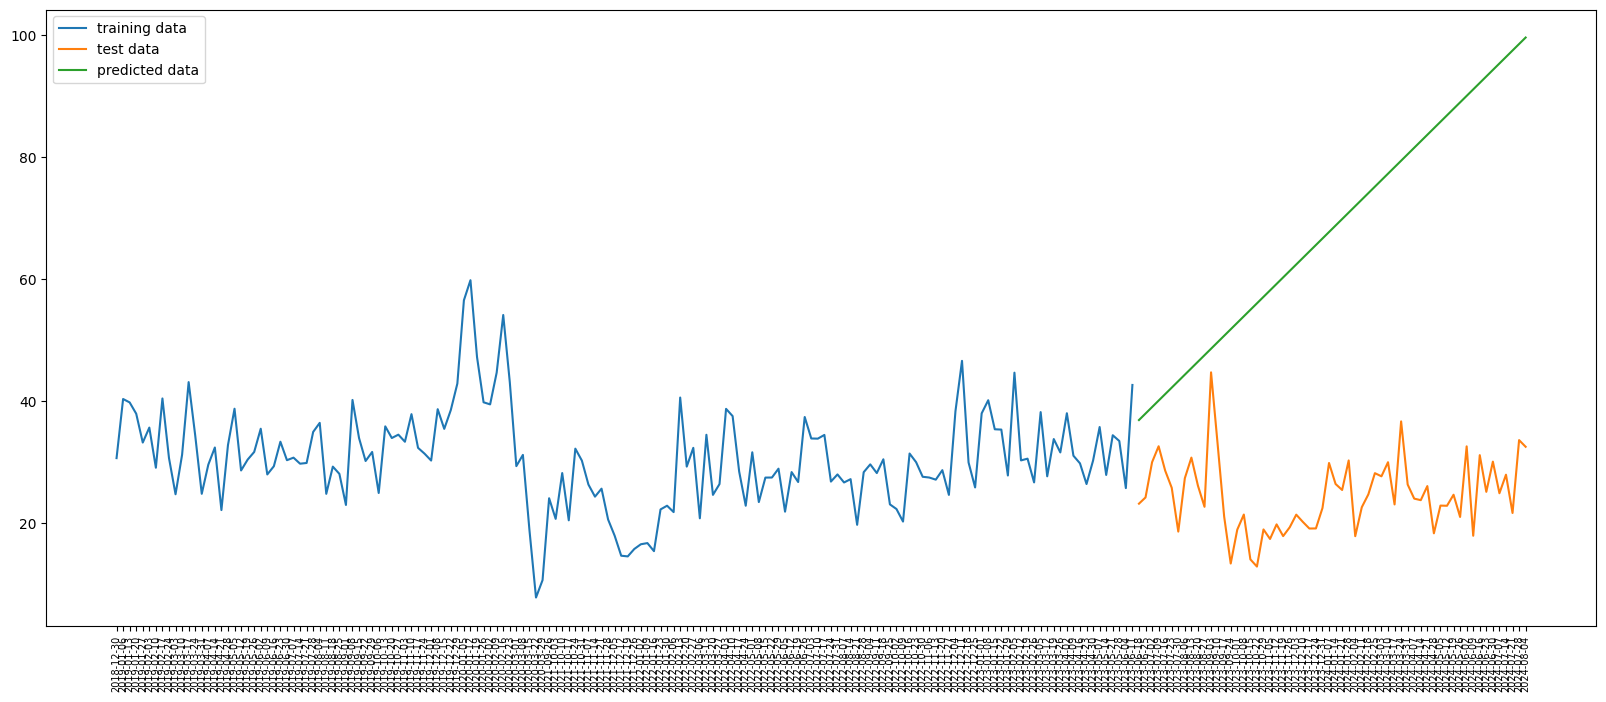

In [62]:
predict_trends("US")

RMS error for Spain's data is 35.711
Upward trend: 0.10872


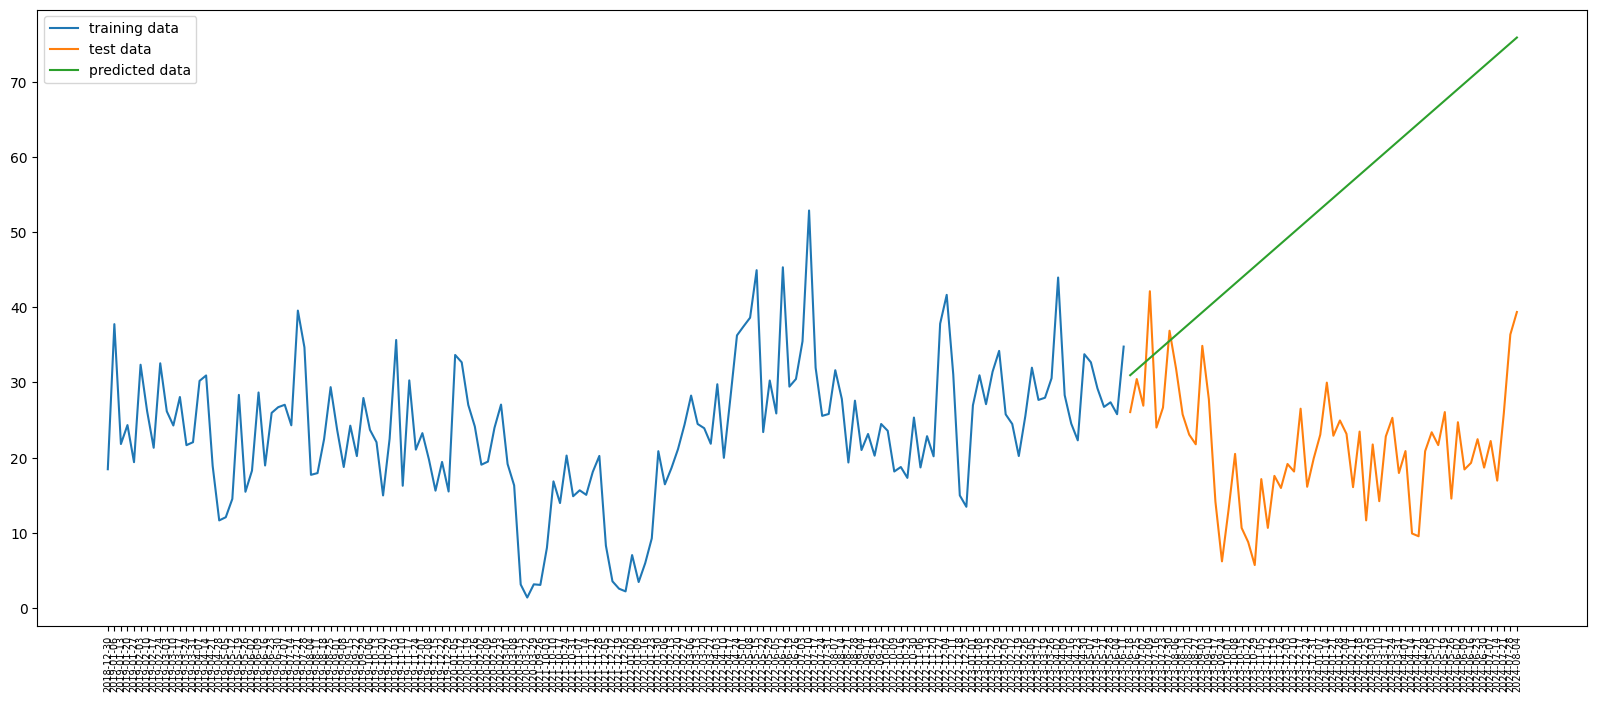

In [63]:
predict_trends("ES")

RMS error for France's data is 18.338
Upward trend: 0.06173


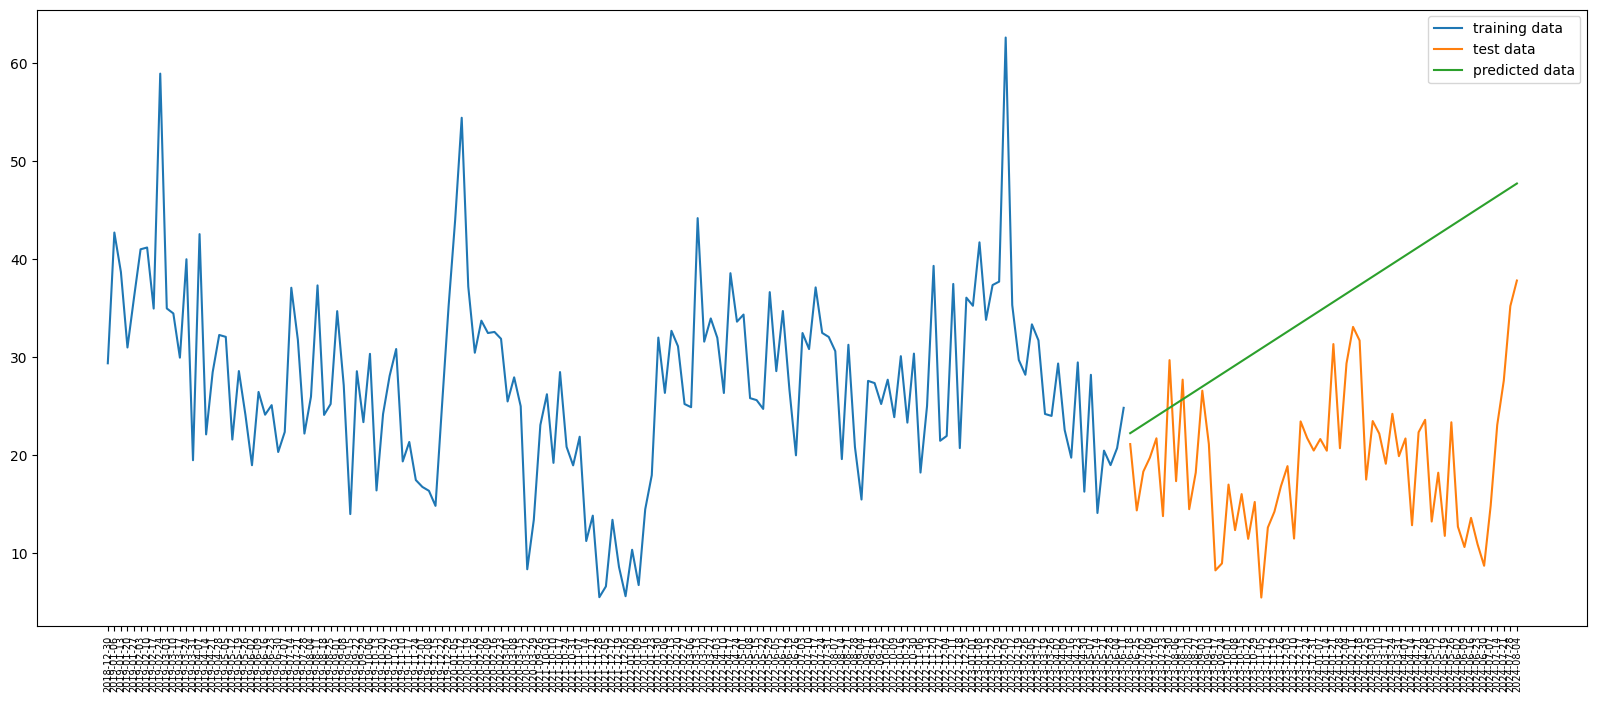

In [64]:
predict_trends("FR")

RMS error for Germany's data is 10.137
Upward trend: 0.03384


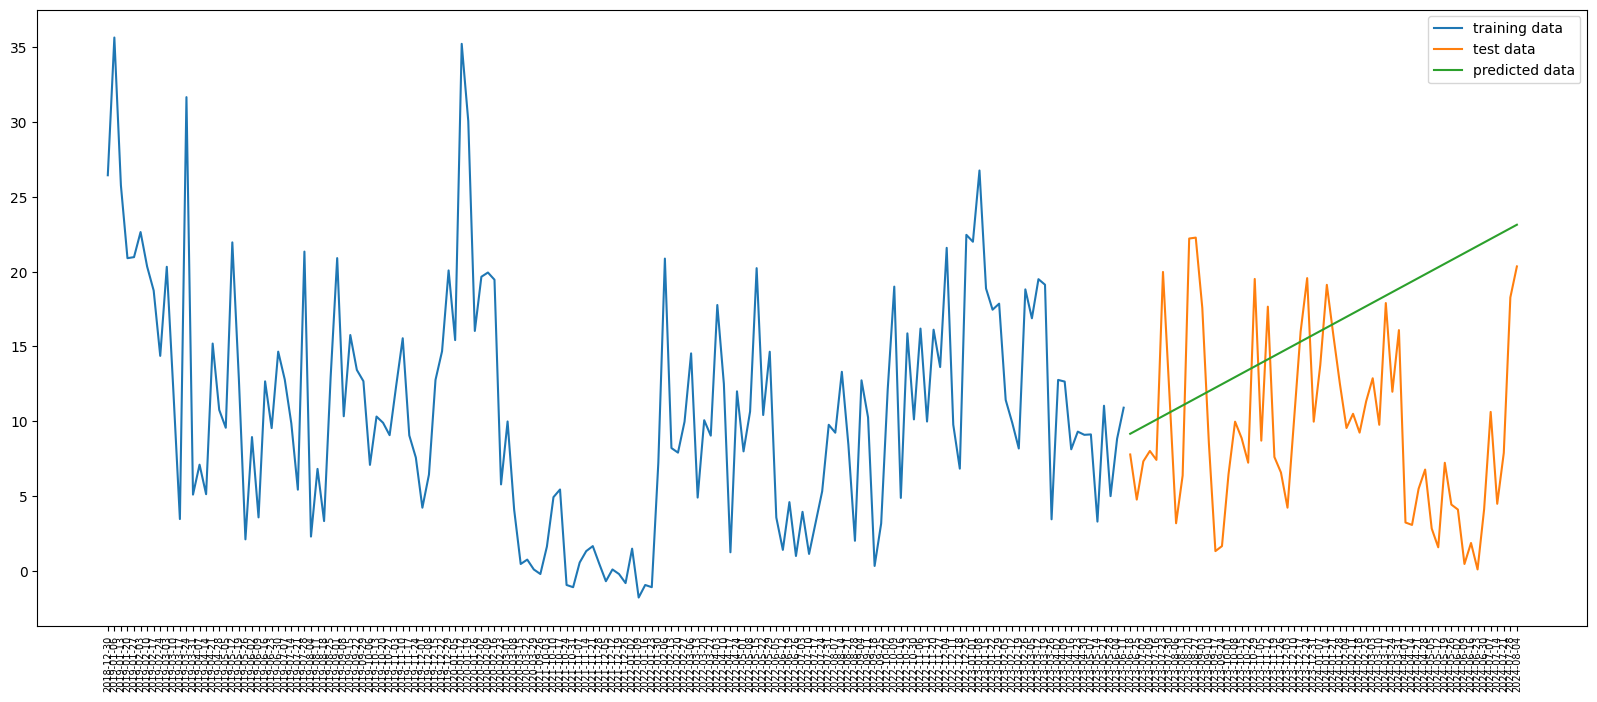

In [66]:
predict_trends("DE")

RMS error for United Kingdom's data is 38.156
Downward trend: -0.13633


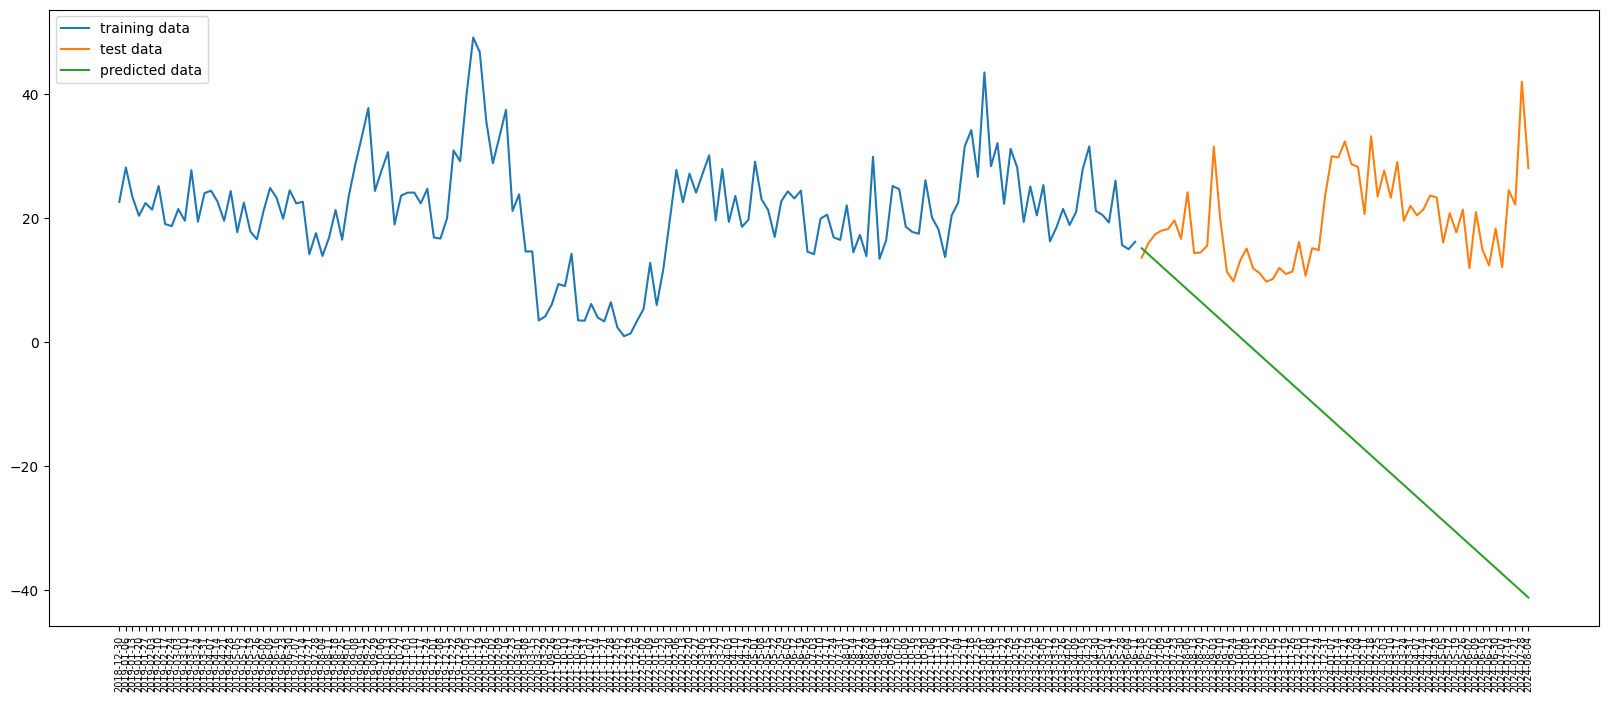

In [67]:
predict_trends("GB")

### Needs Assessment

This part of the analyses uses Google Trends data within Morocco to see if there was a trend in some of the key search terms categories. The search terms comprise of English, French and Arabic terms that could've been used by the local communities or the search and rescue operations staff. The analysis also takes a deeper dive at the admin regions most affected by the earthquake to see if there's any considerable trend for the search terms.  

In [68]:
water_terms = ['water', 'drinking water', 'يشرب الماء', 'ماء', 'eau']

food_terms = ['grocery store', 'souk', 'خضروات', 'restaurant near me', 'store' ]

ph_terms = ['toilette', 'الحمام', 'toilet']

hosp_terms = ['مستشفى', 'hôpital', 'clinique', 'عيادة', 'hospital', 'clinic', 'medical supply', 'medicines', 'الأدوية']

In [71]:
beq_water = get_df(water_terms, 'MA', start_date='2023-07', end_date = "2023-08")
aeq_water = get_df(water_terms, 'MA', start_date='2023-09', end_date = '2023-09')

beq_food = get_df(food_terms, 'MA', start_date='2023-07', end_date = "2023-08")
aeq_food = get_df(food_terms, 'MA', start_date='2023-09', end_date = '2023-09')

beq_ph = get_df(ph_terms, 'MA', start_date='2023-07', end_date = "2023-08")
aeq_ph = get_df(ph_terms, 'MA', start_date='2023-09', end_date = '2023-09')

beq_hosp = get_df(hosp_terms, 'MA', start_date='2023-07', end_date = "2023-08")
aeq_hosp = get_df(hosp_terms, 'MA', start_date='2023-09', end_date = '2023-09')

In [75]:
def plot_needs_trends(before, after, keyword, region = None):
    plt.figure(figsize=(16, 6))
    before_agg = before.groupby(['date'])[['value']].mean()
    after_agg = after.groupby(['date'])[['value']].mean()
    result_bef = np.polyfit(pd.factorize(before_agg.index)[0], list(before_agg.value), 1)
    trendpoly_bef = np.poly1d(result_bef) 
    result_aft = np.polyfit(pd.factorize(after_agg.index)[0], list(after_agg.value), 1)
    trendpoly_aft = np.poly1d(result_aft) 
    plt.plot(before_agg['value'], label='Before Earthquake')
    plt.plot(before_agg.index, trendpoly_bef(pd.factorize(before_agg.index)[0]), label = 'Trendline - Before Earthquake')
    plt.plot(after_agg['value'], label='After Earthquake')
    plt.plot(after_agg.index, trendpoly_aft(pd.factorize(after_agg.index)[0]), label = 'Trendline - After Earthquake')
    plt.xticks(rotation = 90, fontsize = 7);
    plt.ylabel("Scaled Search Results Score", fontsize = 12)
    if region:
        plt.title(f"Search trends for {keyword} related keywords before and after the earthquake in {region} region")
    else:
        plt.title(f"Search trends for {keyword} related keywords before and after the earthquake")
    plt.legend(loc='best');
    plt.show()

In [78]:
def get_needs_trends(df):
    df_grp = df.groupby(['date'])[['value']].mean()

    stat = trenddetector(pd.factorize(df_grp.index)[0], df_grp.value)

    if stat>0:
        print(f"Upward trend: {stat}")
    elif stat<0:
        print(f"Downward trend: {stat}")
    else:
        print("No trend")

Analyzing the trends of search keywords for before and after the earthquake period for Morocco to see if there was any considerable changes in search for these key topics

Trends for before earthquake period of water terms
Upward trend: 0.012832716375814762
Trends for after earthquake period of water terms
Upward trend: 0.1644493882091208


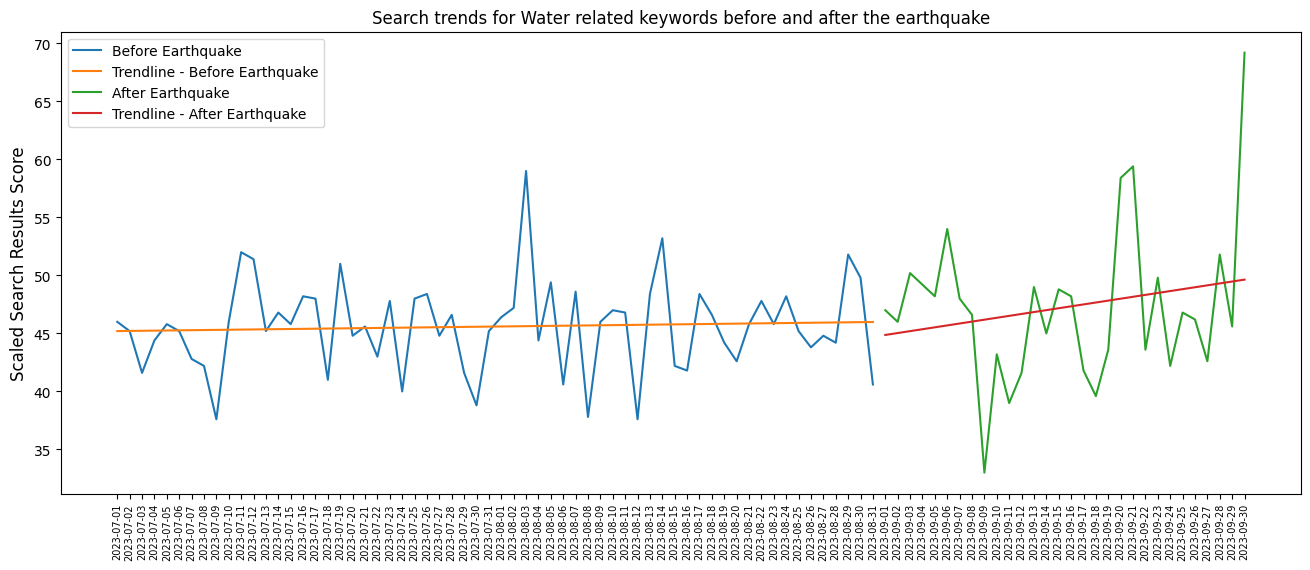

In [79]:
print("Trends for before earthquake period of water terms")
get_needs_trends(beq_water)
print("Trends for after earthquake period of water terms")
get_needs_trends(aeq_water)
plot_needs_trends(beq_water, aeq_water, 'Water')

Trends for before earthquake period of food terms
Upward trend: 0.11815869658281063
Trends for after earthquake period of food terms
Downward trend: -0.10100111234705306


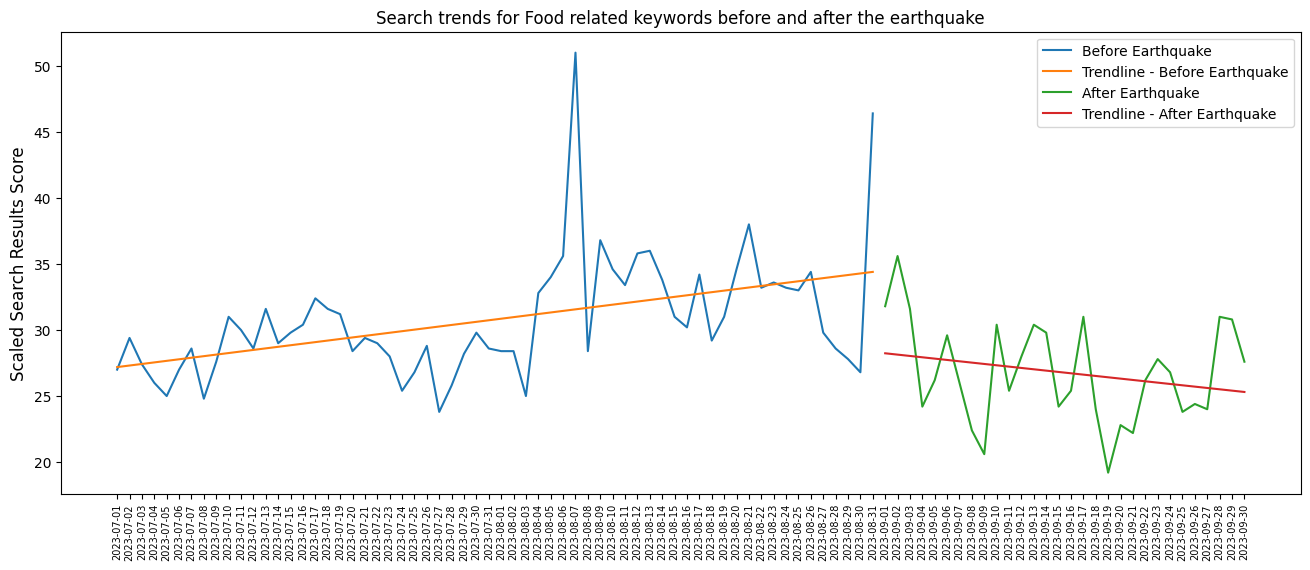

In [83]:
print("Trends for before earthquake period of food terms")
get_needs_trends(beq_food)
print("Trends for after earthquake period of food terms")
get_needs_trends(aeq_food)
plot_needs_trends(beq_food, aeq_food, 'Food')

Trends for before earthquake period of personal hygiene terms
Upward trend: 0.05202588703381912
Trends for after earthquake period of personal hygiene terms
Downward trend: -0.17575083426029123


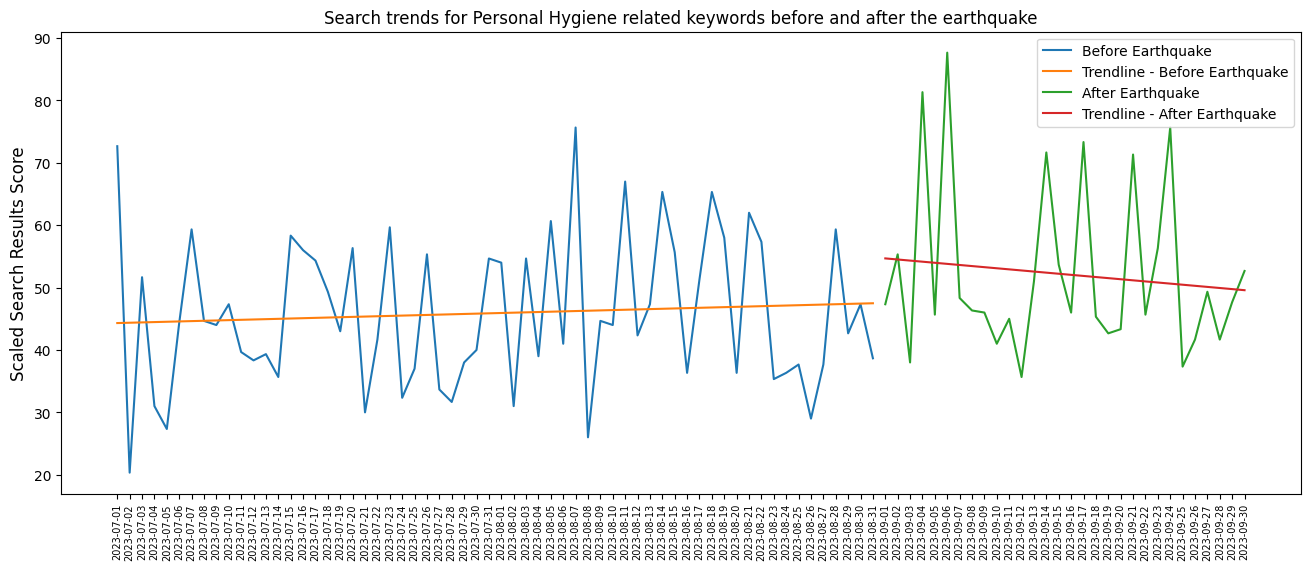

In [81]:
print("Trends for before earthquake period of personal hygiene terms")
get_needs_trends(beq_ph)
print("Trends for after earthquake period of personal hygiene terms")
get_needs_trends(aeq_ph)
plot_needs_trends(beq_ph, aeq_ph, 'Personal Hygiene')

Trends for before earthquake period of hospital terms
Downward trend: -0.11988002204818737
Trends for after earthquake period of hospital terms
Downward trend: -0.021826721048078757


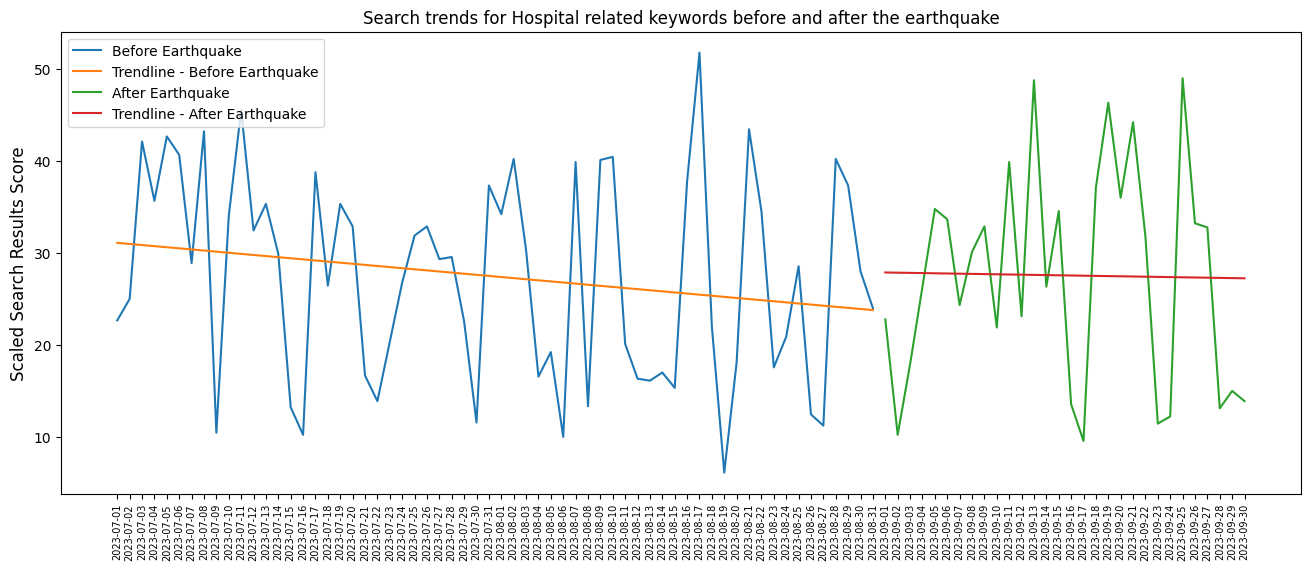

In [82]:
print("Trends for before earthquake period of hospital terms")
get_needs_trends(beq_hosp)
print("Trends for after earthquake period of hospital terms")
get_needs_trends(aeq_hosp)
plot_needs_trends(beq_hosp, aeq_hosp, 'Hospital')

##### Analyzing data at subnational regions for impacted areas

Béni Mellal-Khénifra Region

Trends for Béni Mellal-Khénifra before earthquake period of water terms
Downward trend: -0.04214449396892549
Trends for Béni Mellal-Khénifra after earthquake period of water terms
Upward trend: 0.048943270300333706


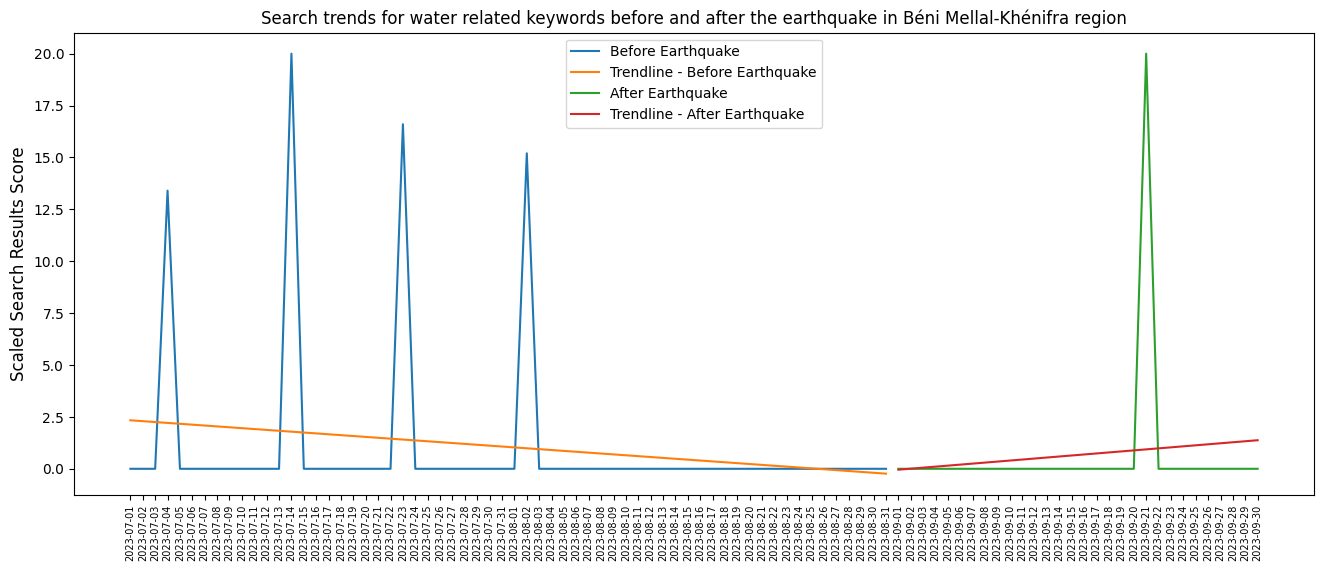

============*****=================
Trends for Béni Mellal-Khénifra before earthquake period of food terms
Downward trend: -0.03563748079877111
Trends for Béni Mellal-Khénifra after earthquake period of food terms
Upward trend: 0.08600667408231343


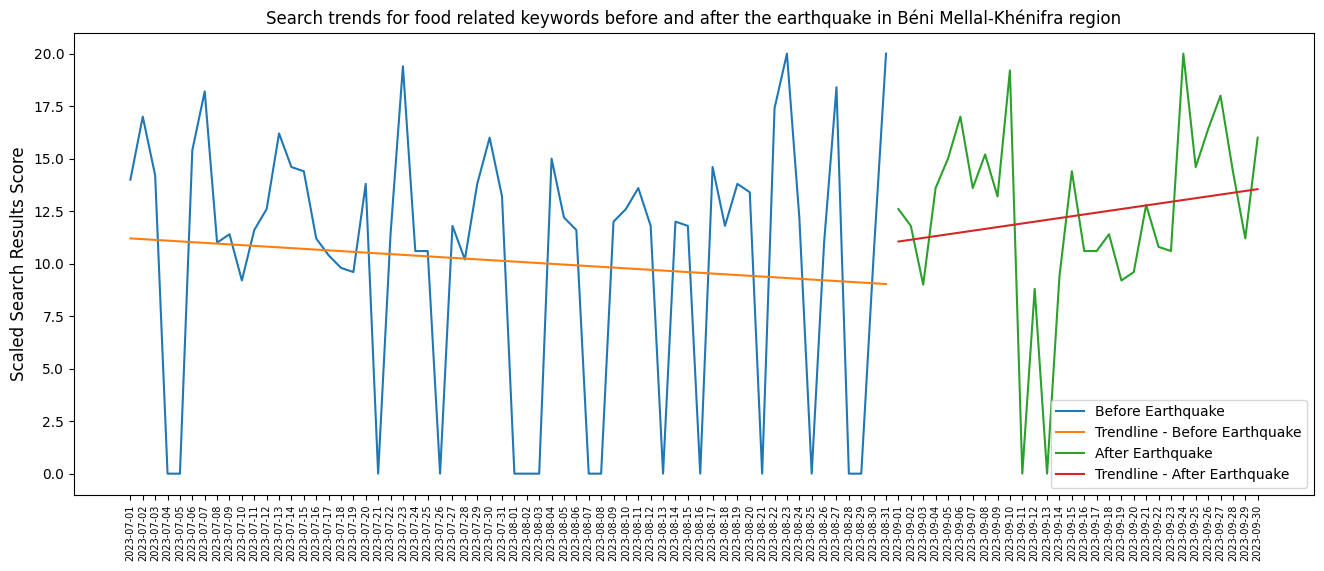

============*****=================
Trends for Béni Mellal-Khénifra before earthquake period of personal hygiene terms
No trend
Trends for Béni Mellal-Khénifra after earthquake period of personal hygiene terms
Downward trend: -0.13348164627363762


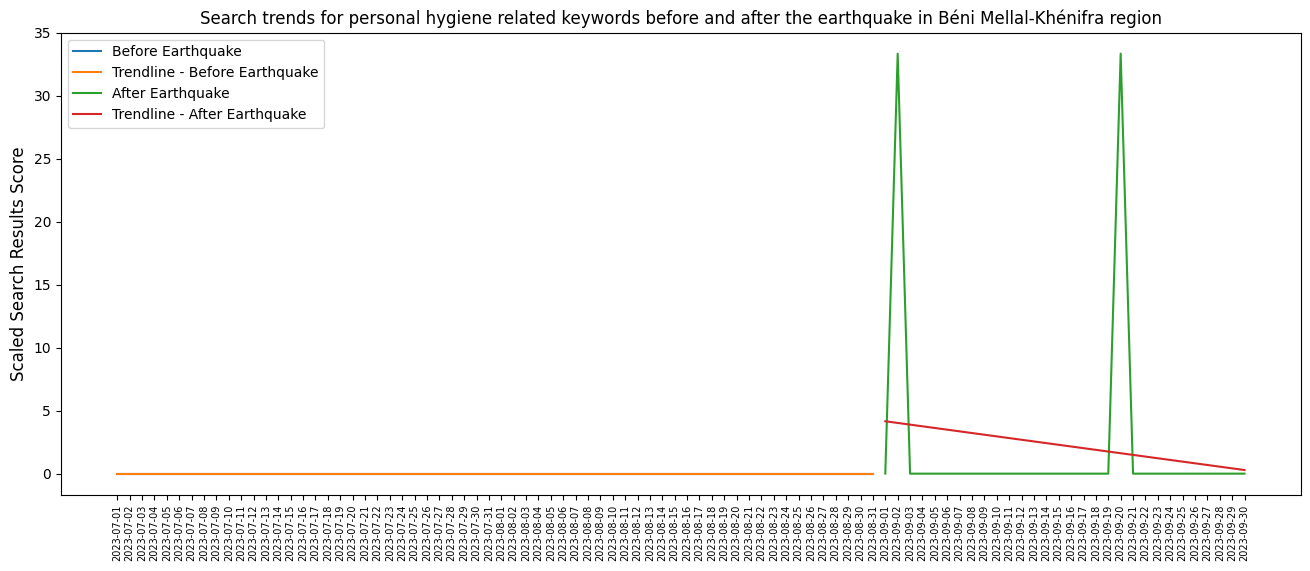

============*****=================
Trends for Béni Mellal-Khénifra before earthquake period of hospital terms
Downward trend: -0.013808096832951436
Trends for Béni Mellal-Khénifra after earthquake period of hospital terms
Upward trend: 0.1460635273760969


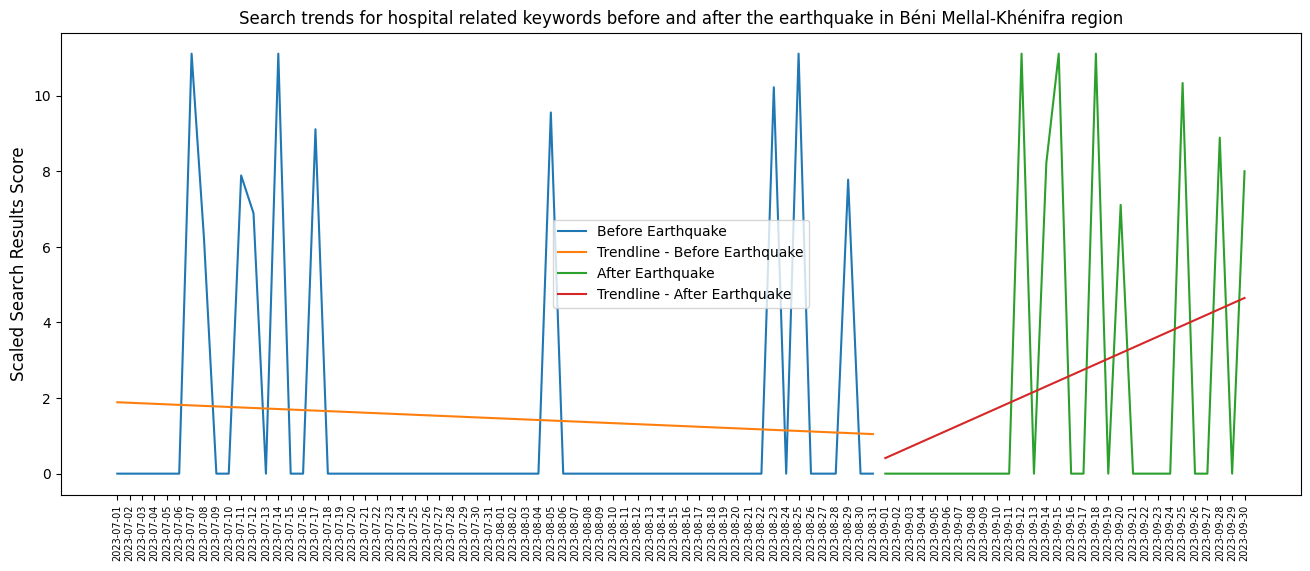

============*****=================


In [84]:
needs_terms = {"water" : water_terms, "food" : food_terms, "personal hygiene" : ph_terms, "hospital" : hosp_terms}

for terms in needs_terms.keys():
    bef = get_df_ht(needs_terms[terms], "MA-05", start_date='2023-07', end_date = "2023-08")
    aft = get_df_ht(needs_terms[terms], "MA-05", start_date='2023-09', end_date = '2023-09')

    print(f"Trends for Béni Mellal-Khénifra before earthquake period of {terms} terms")
    get_needs_trends(bef)
    print(f"Trends for Béni Mellal-Khénifra after earthquake period of {terms} terms")
    get_needs_trends(aft)
    plot_needs_trends(bef, aft, terms, 'Béni Mellal-Khénifra')
    print("============*****=================")

Marrakech-Safi Region

In [85]:
# for terms in needs_terms.keys():
#     bef = get_df_ht(needs_terms[terms], "MA-07", start_date='2023-07', end_date = "2023-08")
#     aft = get_df_ht(needs_terms[terms], "MA-07", start_date='2023-09', end_date = '2023-09')

#     print(f"Trends for Marrakech-Safi region before earthquake period of {terms} terms")
#     get_needs_trends(bef)
#     print(f"Trends for Marrakech-Safi region after earthquake period of {terms} terms")
#     get_needs_trends(aft)
#     plot_needs_trends(bef, aft, terms, 'Marrakech-Safi')
#     print("============*****=================")

Souss-Massa Region

In [86]:
# for terms in needs_terms.keys():
#     bef = get_df_ht(needs_terms[terms], "MA-09", start_date='2023-07', end_date = "2023-08")
#     aft = get_df_ht(needs_terms[terms], "MA-09", start_date='2023-09', end_date = '2023-09')

#     print(f"Trends for Souss-Massa region before earthquake period of {terms} terms")
#     get_needs_trends(bef)
#     print(f"Trends for Souss-Massa region after earthquake period of {terms} terms")
#     get_needs_trends(aft)
#     plot_needs_trends(bef, aft, terms, 'Souss-Massa')
#     print("============*****=================")

## Excercise
Using Google Trends Free Tool download the necessary data to study how "name of the crisis" could impact the tourism in "name_country". Use country x, y and z as residence of visiting people